In [1]:
library(tidyverse)
library(Seurat)
library(patchwork)
library(sctransform)
library(harmony)
options(stringsAsFactors = FALSE)
# options(repr.plot.width=5, repr.plot.height=5)

Warning message:
“package ‘tidyverse’ was built under R version 4.2.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘tidyr’ was built under R version 4.2.2”
Warning message:
“package ‘readr’ was built under R version 4.2.2”
Warning message:
“package ‘purrr’ was built under R version 4.2.2”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.2”
Warning message:
“package ‘forcats’ was built under R version 4.2.2”
Warning message:
“package ‘lubridate’ was built under R version 4.2.2”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2 

In [2]:
sdata <- readRDS('data/hauser20/embryonic-smg-integrated.rds')

In [4]:
sdata

An object of class Seurat 
25134 features across 17727 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [7]:
sdata@meta.data %>% colnames(.)

[1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
 [4] "percent.mt"             "RNA_snn_res.0.6"        "seurat_clusters"       
 [7] "stage"                  "CellType"               "sample"                
[10] "RNA_snn_res.0.9"        "RNA_snn_res.0.5"        "integrated_snn_res.0.6"
[13] "celltype.stage"         "celltype.fixed"         "subpopulations"

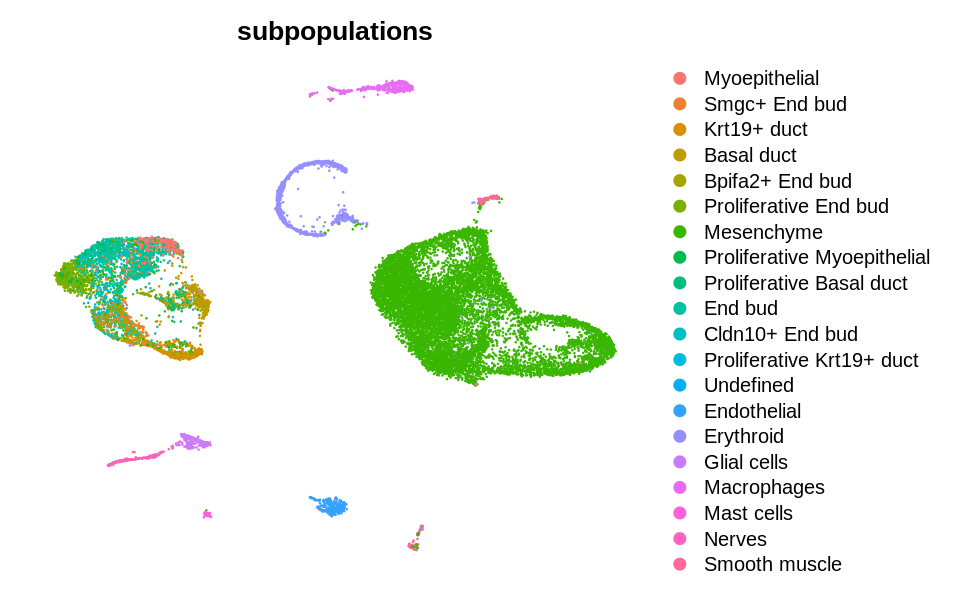

In [18]:
options(repr.plot.width=8, repr.plot.height=5)
DimPlot(sdata, reduction = "umap", group.by = "subpopulations") + NoAxes()

In [3]:
edata <- readRDS('data/hauser20//postnatal-smg-integrated.rds')

In [9]:
edata

An object of class Seurat 
21951 features across 6995 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

In [10]:
edata@meta.data %>% colnames(.)

[1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
 [4] "percent.mt"             "RNA_snn_res.0.9"        "seurat_clusters"       
 [7] "stage"                  "CellType"               "sample"                
[10] "sex"                    "integrated_snn_res.0.9" "celltype.stage"        
[13] "celltype.stage.sex"     "integrated_snn_res.0.6" "celltype.fixed"        
[16] "subpopulations"

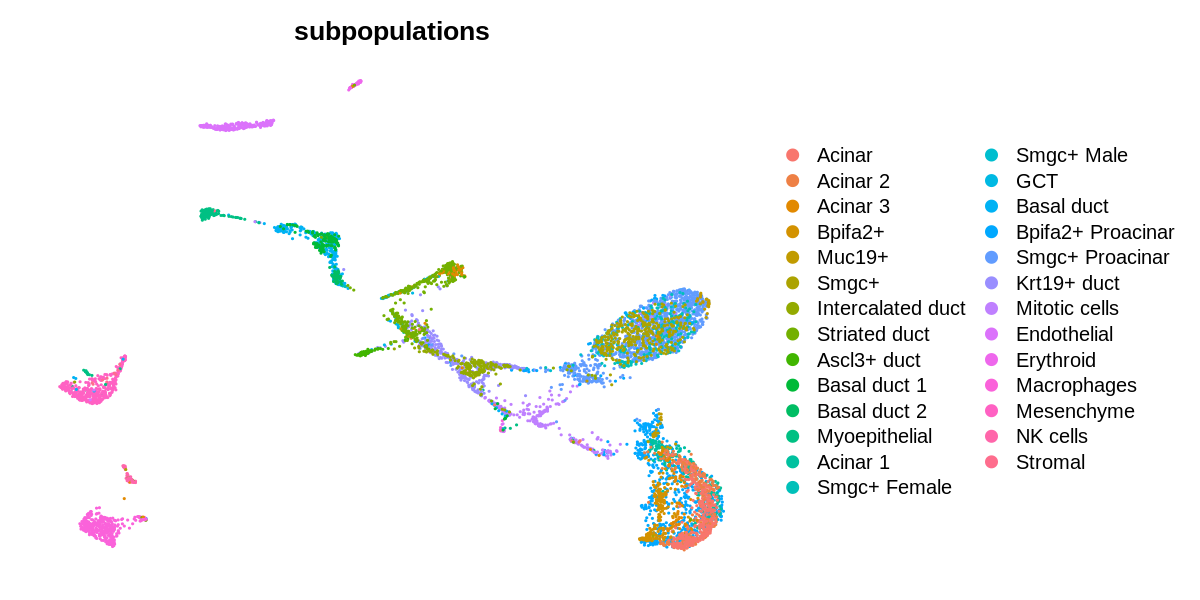

In [17]:
options(repr.plot.width=10, repr.plot.height=5)
DimPlot(edata, reduction = "umap", group.by = "subpopulations") + NoAxes()

In [ ]:
# subset(x = e12smg, subset = nFeature_RNA > 200 & nFeature_RNA < 6500 & percent.mt < 5)

In [6]:
sdata@reductions$umap@cell.embeddings

,UMAP_1,UMAP_2
AAACCTGAGACTCGGA-1_1,1.761666,2.73769238
AAACCTGAGATCGGGT-1_1,4.609205,-2.19160482
AAACCTGAGTCCTCCT-1_1,2.524189,-1.33068976
AAACCTGCAATGACCT-1_1,2.943088,-1.02585462
AAACCTGCACCATGTA-1_1,5.570754,-2.20355103
AAACCTGCATATACGC-1_1,2.778243,-1.29408190
AAACCTGCATCCCACT-1_1,3.830065,1.41959610
AAACCTGCATCCTTGC-1_1,4.131651,0.44653398
AAACCTGGTTAAGATG-1_1,1.808080,1.25919202
AAACCTGGTTCAGCGC-1_1,-1.359010,-12.36162588


In [8]:
sdata@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.6,seurat_clusters,stage,CellType,sample,RNA_snn_res.0.9,RNA_snn_res.0.5,integrated_snn_res.0.6,celltype.stage,celltype.fixed,subpopulations
,<chr>,<dbl>,<int>,<dbl>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<fct>
AAACCTGAGACTCGGA-1_1,SeuratProject,6354,2536,1.9200504,0,1,E12,Mesenchyme,E12,NA,NA,1,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGAGATCGGGT-1_1,SeuratProject,6091,2527,1.0999836,4,2,E12,Mesenchyme,E12,NA,NA,2,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGAGTCCTCCT-1_1,SeuratProject,8179,3067,1.4304927,1,0,E12,Mesenchyme,E12,NA,NA,0,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGCAATGACCT-1_1,SeuratProject,6072,2594,1.5316206,1,0,E12,Mesenchyme,E12,NA,NA,0,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGCACCATGTA-1_1,SeuratProject,8776,3169,1.0711030,4,2,E12,Mesenchyme,E12,NA,NA,2,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGCATATACGC-1_1,SeuratProject,5951,2602,1.1426651,4,0,E12,Mesenchyme,E12,NA,NA,0,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGCATCCCACT-1_1,SeuratProject,5301,2327,1.4525561,0,3,E12,Mesenchyme,E12,NA,NA,3,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGCATCCTTGC-1_1,SeuratProject,9493,3153,1.1692826,0,0,E12,Mesenchyme,E12,NA,NA,0,E12_Mesenchyme,Mesenchyme,Mesenchyme
AAACCTGGTTAAGATG-1_1,SeuratProject,4966,2318,1.1880789,0,1,E12,Mesenchyme,E12,NA,NA,1,E12_Mesenchyme,Mesenchyme,Mesenchyme


In [9]:
write.csv(matrix(rownames(sdata@assays$RNA@counts), ncol=1), row.names=FALSE, file='data/hauser20/embryonic-smg-integrated_features.csv')
write.csv(sdata@meta.data, file='data/hauser20/embryonic-smg-integrated_metadata.csv')
write.csv(sdata@reductions$umap@cell.embeddings, file='data/hauser20/embryonic-smg-integrated_umap.csv')
Matrix::writeMM(sdata@assays$RNA@counts, 'data/hauser20/embryonic-smg-integrated_counts.mtx')

NULL

In [10]:
write.csv(matrix(rownames(edata@assays$RNA@counts), ncol=1), row.names=FALSE, file='data/hauser20/postnatal-smg-integrated_features.csv')
write.csv(edata@meta.data, file='data/hauser20/postnatal-smg-integrated_metadata.csv')
write.csv(edata@reductions$umap@cell.embeddings, file='data/hauser20/postnatal-smg-integrated_umap.csv')
Matrix::writeMM(edata@assays$RNA@counts, 'data/hauser20/postnatal-smg-integrated_counts.mtx')

NULL